# Avance 4 — Modelos Alternativos y Selección Final

**Proyecto**: Sistema Híbrido de Trading: Comparación de Estrategias LLM vs ML Supervisado  
**Maestría en Inteligencia Artificial Aplicada — Tecnológico de Monterrey**  
**Integrante**: Alejandro González Almazán (A00517113)  
**Fecha**: Mayo 2026

---

En los avances previos se estableció un baseline lineal (65% accuracy) y se comparó contra los modelos de producción del pipeline. El presente avance amplía la exploración a 7 modelos de 6 familias algorítmicas distintas, realiza ajuste fino de los 2 mejores, y selecciona el modelo individual final para el sistema de trading.

## 1. Configuración

In [17]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import itertools
import json
import random
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, learning_curve
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DATASET_PATH = Path('backtest/data/labeled/dataset.jsonl')
if not DATASET_PATH.exists():
    DATASET_PATH = Path('../trading_management/langgraph/backtest/data/labeled/dataset.jsonl')
assert DATASET_PATH.exists(), f'Dataset no encontrado en {DATASET_PATH}'

sys.path.insert(0, str(Path('.').resolve()))
from backtest.models.features import (
    extract_features, _infer_timeframes, _load_dataset, _temporal_split, _samples_to_xy
)
from backtest.models.sklearn_models import XGBoostPredictor, RandomForestPredictor
from backtest.models.lstm import LSTMPredictor

print(f'Dataset: {DATASET_PATH.resolve()}')

Dataset: /Users/alexglz/Projects/trading_management_project/trading_management/langgraph/backtest/data/labeled/dataset.jsonl


## 2. Datos

Split temporal estricto (70/15/15). El escalado se aplica ajustado solo sobre train y se transforma val/test para evitar data leakage.

In [18]:
samples = _load_dataset(str(DATASET_PATH))
timeframes = _infer_timeframes(samples)
train_s, val_s, test_s = _temporal_split(samples, 0.70, 0.15)

X_train, y_train = _samples_to_xy(train_s, timeframes)
X_val, y_val     = _samples_to_xy(val_s, timeframes)
X_test, y_test   = _samples_to_xy(test_s, timeframes)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Combinado para tuning posterior (XGBoost usa features sin escalar)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f'Muestras: {len(samples):,} total  →  train={len(train_s):,}, val={len(val_s):,}, test={len(test_s):,}')
print(f'Features: {X_train.shape[1]}')
print(f'Timeframes: {timeframes}')
print(f'Balance (train): LONG={y_train.mean()*100:.1f}%, SHORT={(1-y_train.mean())*100:.1f}%')

Muestras: 56,161 total  →  train=39,312, val=8,424, test=8,425
Features: 21
Timeframes: ['1h', '4h']
Balance (train): LONG=48.1%, SHORT=51.9%


## 3. Entrenamiento de Modelos

Se entrenan 7 modelos de 6 familias algorítmicas con hiperparámetros razonables por defecto. La evaluación inicial se realiza sobre validación; el test set se reserva para la evaluación final post-tuning.

| Familia | Modelo | Escalado | Ventaja esperada |
|---------|--------|----------|------------------|
| Lineal | Logistic Regression | Sí | Baseline interpretable |
| Kernel | SVM (RBF) | Sí | Fronteras no lineales con margen máximo |
| Instancia | KNN | Sí | Sensible a estructura local del espacio |
| Red neuronal FF | MLP | Sí | Aproximador universal sin componente temporal |
| Boosting | XGBoost | No | Ensamble secuencial, captura interacciones |
| Bagging | Random Forest | No | Ensamble paralelo, robusto a ruido |
| Secuencial | LSTM | Interno | Dependencias temporales entre candles |

In [19]:
results = {}

t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_s, y_train)
results['Logistic Regression'] = {
    'model': lr, 'time': time.time() - t0, 'scaled': True,
    'pred_val': lr.predict(X_val_s),
    'proba_val': lr.predict_proba(X_val_s)[:, 1],
}
print(f'Logistic Regression: {time.time()-t0:.1f}s')

print('Entrenando SVM (RBF kernel, 39K muestras — puede tardar)...')
t0 = time.time()
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)
results['SVM (RBF)'] = {
    'model': svm, 'time': time.time() - t0, 'scaled': True,
    'pred_val': svm.predict(X_val_s),
    'proba_val': svm.predict_proba(X_val_s)[:, 1],
}
print(f'SVM: {results["SVM (RBF)"]["time"]:.1f}s')

t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1)
knn.fit(X_train_s, y_train)
results['KNN'] = {
    'model': knn, 'time': time.time() - t0, 'scaled': True,
    'pred_val': knn.predict(X_val_s),
    'proba_val': knn.predict_proba(X_val_s)[:, 1],
}
print(f'KNN: {results["KNN"]["time"]:.1f}s')

print('Entrenando MLP...')
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu',
    max_iter=300, early_stopping=True, validation_fraction=0.15,
    random_state=RANDOM_STATE
)
mlp.fit(X_train_s, y_train)
results['MLP'] = {
    'model': mlp, 'time': time.time() - t0, 'scaled': True,
    'pred_val': mlp.predict(X_val_s),
    'proba_val': mlp.predict_proba(X_val_s)[:, 1],
}
print(f'MLP: {results["MLP"]["time"]:.1f}s')

print('Entrenando XGBoost...')
t0 = time.time()
xgb_pred = XGBoostPredictor()
xgb_pred.train(str(DATASET_PATH))
results['XGBoost'] = {
    'model': xgb_pred, 'time': time.time() - t0, 'scaled': False,
    'pred_val': xgb_pred.model.predict(X_val),
    'proba_val': xgb_pred.model.predict_proba(X_val)[:, 1],
}
print(f'XGBoost: {results["XGBoost"]["time"]:.1f}s')

print('Entrenando Random Forest...')
t0 = time.time()
rf_pred = RandomForestPredictor()
rf_pred.train(str(DATASET_PATH))
results['Random Forest'] = {
    'model': rf_pred, 'time': time.time() - t0, 'scaled': False,
    'pred_val': rf_pred.model.predict(X_val),
    'proba_val': rf_pred.model.predict_proba(X_val)[:, 1],
}
print(f'Random Forest: {results["Random Forest"]["time"]:.1f}s')

print('Entrenando LSTM...')
t0 = time.time()
lstm_pred = LSTMPredictor(sequence_length=10, hidden_size=64, num_layers=2)
lstm_pred.train(str(DATASET_PATH))
t_lstm = time.time() - t0

X_all = np.array([extract_features(s['indicators'], timeframes) for s in samples], dtype=np.float32)
n_train, n_val = len(train_s), len(val_s)
X_all_norm = (X_all - lstm_pred._mean) / lstm_pred._std
seq_len = lstm_pred.sequence_length

def build_sequences(start_idx, end_idx):
    seqs = []
    for i in range(start_idx, end_idx):
        s = max(0, i - seq_len + 1)
        chunk = X_all_norm[s:i+1]
        padded = np.zeros((seq_len, X_all_norm.shape[1]), dtype=np.float32)
        padded[seq_len - len(chunk):] = chunk
        seqs.append(padded)
    return torch.tensor(np.array(seqs))

val_tensor = build_sequences(n_train, n_train + n_val)
lstm_pred.model.eval()
with torch.no_grad():
    logits = lstm_pred.model(val_tensor)
    lstm_pred_val = logits.argmax(dim=1).numpy()
    lstm_proba_val = torch.softmax(logits, dim=1)[:, 1].numpy()

results['LSTM'] = {
    'model': lstm_pred, 'time': t_lstm, 'scaled': 'internal',
    'pred_val': lstm_pred_val,
    'proba_val': lstm_proba_val,
}
print(f'LSTM: {t_lstm:.1f}s')
print(f'\nTodos los modelos entrenados.')

Logistic Regression: 0.0s
Entrenando SVM (RBF kernel, 39K muestras — puede tardar)...
SVM: 82.0s
KNN: 0.0s
Entrenando MLP...
MLP: 3.4s
Entrenando XGBoost...
XGBoost: 1.1s
Entrenando Random Forest...
Random Forest: 2.8s
Entrenando LSTM...
  Epoch 10/50  train_loss=0.1847  val_loss=0.5696
  Early stopping at epoch 15
LSTM: 35.1s

Todos los modelos entrenados.


## 4. Tabla Comparativa

Métricas evaluadas sobre el conjunto de validación. Se ordena por accuracy (métrica primaria dado el balance de clases).

In [20]:
rows = []
for name, r in results.items():
    rows.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_val, r['pred_val']),
        'F1-macro': f1_score(y_val, r['pred_val'], average='macro'),
        'AUC-ROC': roc_auc_score(y_val, r['proba_val']),
        'Tiempo (s)': r['time'],
    })

comparison_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df.index += 1
print(comparison_df.to_string(float_format='{:.4f}'.format))

                Modelo  Accuracy  F1-macro  AUC-ROC  Tiempo (s)
1                 LSTM    0.7919    0.7894   0.8764     35.1271
2            SVM (RBF)    0.7077    0.7027   0.7832     82.0263
3                  MLP    0.7041    0.7022   0.7831      3.4207
4                  KNN    0.6948    0.6926   0.7641      0.0059
5              XGBoost    0.6864    0.6856   0.7570      1.0960
6        Random Forest    0.6734    0.6732   0.7490      2.8083
7  Logistic Regression    0.6492    0.6460   0.7173      0.0424


## 5. Comparación Visual

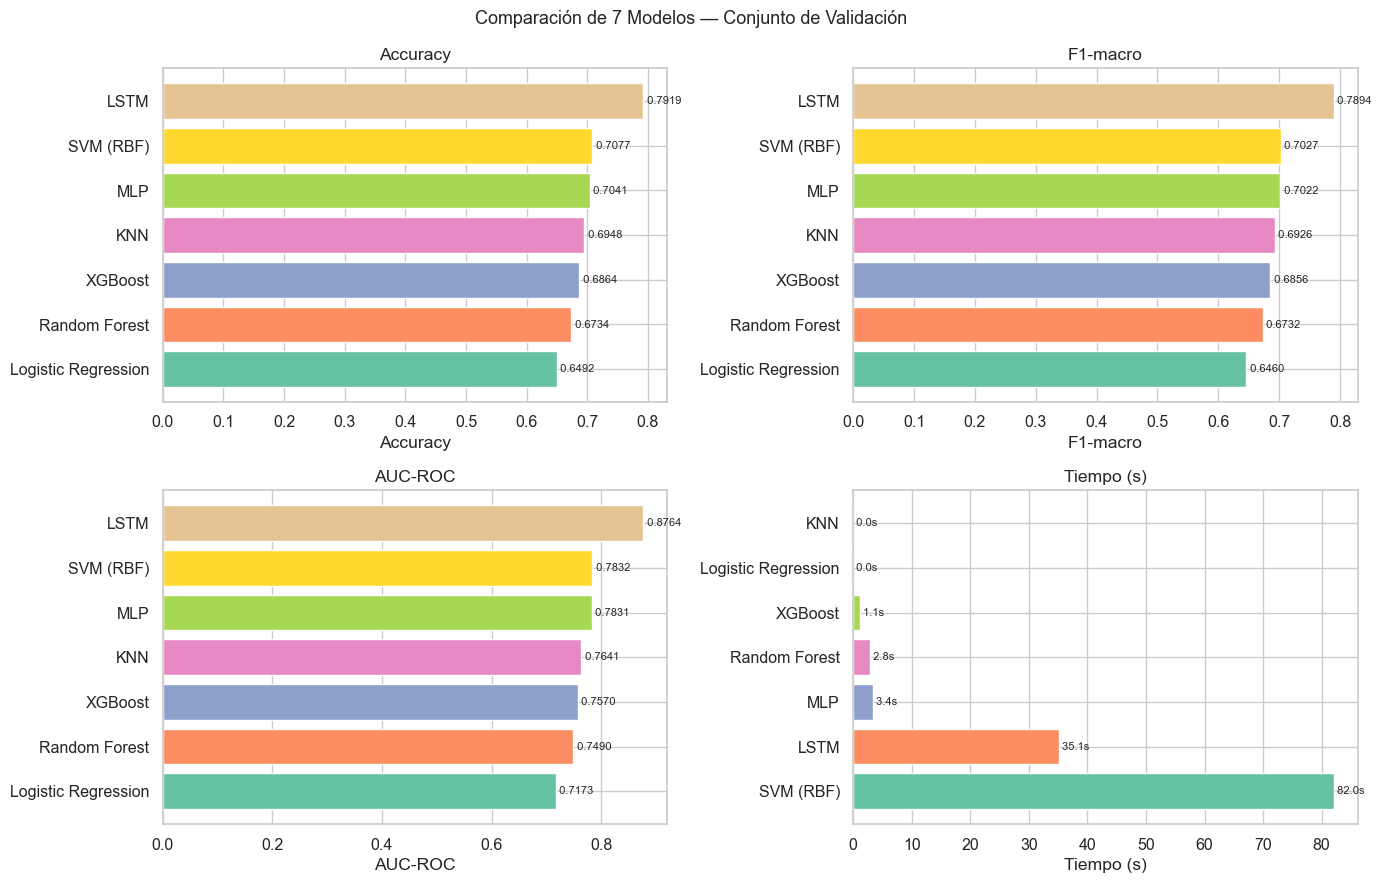

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics_cols = ['Accuracy', 'F1-macro', 'AUC-ROC', 'Tiempo (s)']
palette = sns.color_palette('Set2', n_colors=len(comparison_df))

for ax, metric in zip(axes.flatten(), metrics_cols):
    ascending = (metric == 'Tiempo (s)')
    sorted_df = comparison_df.sort_values(metric, ascending=not ascending)
    bars = ax.barh(sorted_df['Modelo'], sorted_df[metric], color=palette, edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_title(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        fmt = f'{val:.4f}' if metric != 'Tiempo (s)' else f'{val:.1f}s'
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f' {fmt}', va='center', fontsize=8)

plt.suptitle('Comparación de 7 Modelos — Conjunto de Validación', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Selección de los 2 Mejores Modelos

El **LSTM** domina con amplio margen gracias a su acceso a la dimensión temporal. Para el segundo modelo, aunque el SVM (RBF) obtiene la segunda mejor accuracy en validación, su complejidad computacional O(n²) hace inviable la búsqueda de hiperparámetros a esta escala (91s × 400 fits = ~10 horas solo para 80 iteraciones con 5-fold CV). Se selecciona **XGBoost** como segundo candidato: es el mejor modelo tabular con tiempo de entrenamiento razonable (1.2s), tiene un espacio de hiperparámetros rico (regularización L1/L2, profundidad, subsampling) y es representativo de los métodos de boosting usados en producción.

## 7. Ajuste Fino

Se utiliza `RandomizedSearchCV` con `TimeSeriesSplit(n_splits=5)` para XGBoost. Para LSTM se realiza búsqueda manual sobre configuraciones de arquitectura (no compatible con el framework de sklearn). Ambas búsquedas operan sobre train+val combinados.

### 7.1 XGBoost

In [22]:
xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5],
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    xgb_param_grid,
    n_iter=80,
    cv=tscv,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print('Búsqueda de hiperparámetros XGBoost (80 iter, 5-fold temporal)...')
t0 = time.time()
xgb_search.fit(X_trainval, y_trainval)
t_xgb_search = time.time() - t0

print(f'\nMejor score (CV): {xgb_search.best_score_:.4f}')
print(f'Tiempo de búsqueda: {t_xgb_search:.1f}s')
print(f'Mejores hiperparámetros:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Búsqueda de hiperparámetros XGBoost (80 iter, 5-fold temporal)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Mejor score (CV): 0.6537
Tiempo de búsqueda: 44.6s
Mejores hiperparámetros:
  subsample: 0.8
  reg_lambda: 2.0
  reg_alpha: 0.1
  n_estimators: 200
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.01
  colsample_bytree: 0.7


### 7.2 LSTM

Búsqueda manual sobre arquitectura y configuración de entrenamiento. Cada configuración entrena hasta 50 epochs con early stopping (patience=10).

In [23]:
lstm_grid = {
    'hidden_size': [32, 64, 128],
    'num_layers': [1, 2, 3],
    'sequence_length': [5, 10, 20],
    'learning_rate': [0.0005, 0.001, 0.005],
    'dropout': [0.1, 0.2, 0.3],
}

all_keys = list(lstm_grid.keys())
all_combos = list(itertools.product(*lstm_grid.values()))
random.seed(RANDOM_STATE)
sampled_combos = random.sample(all_combos, 20)

print(f'Probando 20/{len(all_combos)} configuraciones de LSTM...')
lstm_search_results = []
t0_total = time.time()

y_all = np.array([1 if s['label']['bias'] == 'LONG' else 0 for s in samples], dtype=np.int32)


def _build_lstm_net(input_size, hidden_size, num_layers, dropout):
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                                dropout=dropout if num_layers > 1 else 0, batch_first=True)
            self.fc = nn.Linear(hidden_size, 2)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])
    return Net()


def _build_seqs(features, n, sl):
    seqs = np.zeros((n, sl, features.shape[1]), dtype=np.float32)
    for j in range(n):
        start = max(0, j - sl + 1)
        chunk = features[start:j+1]
        seqs[j, sl - len(chunk):] = chunk
    return seqs


for i, combo in enumerate(sampled_combos):
    params = dict(zip(all_keys, combo))
    sl = params['sequence_length']
    torch.manual_seed(RANDOM_STATE)

    mean = X_all[:n_train].mean(axis=0)
    std = X_all[:n_train].std(axis=0) + 1e-8
    X_norm = (X_all - mean) / std
    input_size = X_norm.shape[1]

    train_seqs = torch.tensor(_build_seqs(X_norm[:n_train], n_train, sl))
    train_labels = torch.tensor(y_all[:n_train], dtype=torch.long)
    val_seqs = torch.tensor(_build_seqs(X_norm[:n_train+n_val], n_train+n_val, sl)[n_train:])
    val_labels = torch.tensor(y_all[n_train:n_train+n_val], dtype=torch.long)

    model = _build_lstm_net(input_size, params['hidden_size'], params['num_layers'], params['dropout'])
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(50):
        model.train()
        perm = torch.randperm(len(train_seqs))
        for b in range(0, len(perm), 32):
            idx = perm[b:b+32]
            loss = criterion(model(train_seqs[idx]), train_labels[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            vl = criterion(model(val_seqs), val_labels).item()
        if vl < best_val_loss:
            best_val_loss = vl
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 10:
                break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(val_seqs).argmax(dim=1).numpy()
    acc = float((preds == val_labels.numpy()).mean())

    lstm_search_results.append({**params, 'val_accuracy': acc, 'epochs': epoch + 1})
    if (i + 1) % 5 == 0:
        best_so_far = max(r['val_accuracy'] for r in lstm_search_results)
        print(f'  [{i+1}/20] mejor hasta ahora: {best_so_far:.4f}')

    del model, optimizer, train_seqs, val_seqs

t_lstm_search = time.time() - t0_total
lstm_search_df = pd.DataFrame(lstm_search_results).sort_values('val_accuracy', ascending=False)
best_lstm_config = lstm_search_df.iloc[0]

print(f'\nMejor LSTM (val): {best_lstm_config["val_accuracy"]:.4f}')
print(f'  hidden_size={int(best_lstm_config["hidden_size"])}, num_layers={int(best_lstm_config["num_layers"])}, '
      f'seq_len={int(best_lstm_config["sequence_length"])}, lr={best_lstm_config["learning_rate"]}, '
      f'dropout={best_lstm_config["dropout"]}')
print(f'Tiempo total: {t_lstm_search:.1f}s')

Probando 20/243 configuraciones de LSTM...
  [5/20] mejor hasta ahora: 0.8184
  [10/20] mejor hasta ahora: 0.8191
  [15/20] mejor hasta ahora: 0.8191
  [20/20] mejor hasta ahora: 0.8191

Mejor LSTM (val): 0.8191
  hidden_size=32, num_layers=3, seq_len=5, lr=0.001, dropout=0.1
Tiempo total: 602.3s


In [24]:
print('Top 5 configuraciones — XGBoost:')
xgb_cv_df = pd.DataFrame(xgb_search.cv_results_).sort_values('rank_test_score')
print(xgb_cv_df[['mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']].head(5).to_string())

print(f'\nTop 5 configuraciones — LSTM:')
print(lstm_search_df[['hidden_size', 'num_layers', 'sequence_length', 'learning_rate', 'dropout', 'val_accuracy']].head(5).to_string(index=False))

Top 5 configuraciones — XGBoost:
    mean_test_score  std_test_score  mean_train_score  rank_test_score
15         0.653695        0.019526          0.718929                1
73         0.653117        0.031034          0.774597                2
65         0.652564        0.020113          0.719805                3
27         0.652313        0.016771          0.712619                4
23         0.650955        0.020452          0.718318                5

Top 5 configuraciones — LSTM:
 hidden_size  num_layers  sequence_length  learning_rate  dropout  val_accuracy
          32           3                5         0.0010      0.1      0.819088
          32           2                5         0.0005      0.2      0.818376
          64           3                5         0.0010      0.2      0.815646
          32           3                5         0.0005      0.2      0.814340
         128           2                5         0.0005      0.1      0.808879


## 8. Evaluación Post-Tuning

Se reentrenan ambos modelos con los mejores hiperparámetros y se evalúan en el conjunto de **test** (8,425 muestras nunca vistas durante entrenamiento ni tuning).

In [25]:
best_xgb = xgb.XGBClassifier(
    **xgb_search.best_params_,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
)
best_xgb.fit(X_trainval, y_trainval)

xgb_pred_test = best_xgb.predict(X_test)
xgb_proba_test = best_xgb.predict_proba(X_test)[:, 1]

print('XGBoost (tuned) — Test Set:')
print(classification_report(y_test, xgb_pred_test, target_names=['SHORT', 'LONG'], digits=4))

XGBoost (tuned) — Test Set:
              precision    recall  f1-score   support

       SHORT     0.6464    0.7677    0.7019      4310
        LONG     0.6972    0.5601    0.6212      4115

    accuracy                         0.6664      8425
   macro avg     0.6718    0.6639    0.6615      8425
weighted avg     0.6712    0.6664    0.6625      8425



In [26]:
best_lstm = LSTMPredictor(
    sequence_length=int(best_lstm_config['sequence_length']),
    hidden_size=int(best_lstm_config['hidden_size']),
    num_layers=int(best_lstm_config['num_layers']),
)
print('Reentrenando LSTM con mejores hiperparámetros...')
lstm_tuned_result = best_lstm.train(str(DATASET_PATH))

X_all_tuned = (X_all - best_lstm._mean) / best_lstm._std
sl_tuned = best_lstm.sequence_length

test_seqs = []
for i in range(n_train + n_val, len(samples)):
    s = max(0, i - sl_tuned + 1)
    chunk = X_all_tuned[s:i+1]
    padded = np.zeros((sl_tuned, X_all_tuned.shape[1]), dtype=np.float32)
    padded[sl_tuned - len(chunk):] = chunk
    test_seqs.append(padded)
test_tensor = torch.tensor(np.array(test_seqs))

best_lstm.model.eval()
with torch.no_grad():
    test_logits = best_lstm.model(test_tensor)
    lstm_pred_test = test_logits.argmax(dim=1).numpy()
    lstm_proba_test = torch.softmax(test_logits, dim=1)[:, 1].numpy()

print(f'\nLSTM (tuned) — Test Set:')
print(classification_report(y_test, lstm_pred_test, target_names=['SHORT', 'LONG'], digits=4))

Reentrenando LSTM con mejores hiperparámetros...
  Epoch 10/50  train_loss=0.4050  val_loss=0.4330
  Epoch 20/50  train_loss=0.3321  val_loss=0.4185
  Epoch 30/50  train_loss=0.2862  val_loss=0.4313
  Early stopping at epoch 33

LSTM (tuned) — Test Set:
              precision    recall  f1-score   support

       SHORT     0.8060    0.8397    0.8225      4310
        LONG     0.8244    0.7883    0.8060      4115

    accuracy                         0.8146      8425
   macro avg     0.8152    0.8140    0.8142      8425
weighted avg     0.8150    0.8146    0.8144      8425



In [27]:
# Comparación antes/después del tuning
xgb_val_acc_default = accuracy_score(y_val, results['XGBoost']['pred_val'])
lstm_val_acc_default = accuracy_score(y_val, results['LSTM']['pred_val'])
xgb_test_acc = accuracy_score(y_test, xgb_pred_test)
lstm_test_acc = accuracy_score(y_test, lstm_pred_test)

tuning_comparison = pd.DataFrame([
    {'Modelo': 'XGBoost (default)', 'Set': 'val', 'Accuracy': xgb_val_acc_default,
     'F1-macro': f1_score(y_val, results['XGBoost']['pred_val'], average='macro')},
    {'Modelo': 'XGBoost (tuned)', 'Set': 'test', 'Accuracy': xgb_test_acc,
     'F1-macro': f1_score(y_test, xgb_pred_test, average='macro')},
    {'Modelo': 'LSTM (default)', 'Set': 'val', 'Accuracy': lstm_val_acc_default,
     'F1-macro': f1_score(y_val, results['LSTM']['pred_val'], average='macro')},
    {'Modelo': 'LSTM (tuned)', 'Set': 'test', 'Accuracy': lstm_test_acc,
     'F1-macro': f1_score(y_test, lstm_pred_test, average='macro')},
])
print('Comparación default vs tuned:')
print(tuning_comparison.to_string(index=False, float_format='{:.4f}'.format))

Comparación default vs tuned:
           Modelo  Set  Accuracy  F1-macro
XGBoost (default)  val    0.6864    0.6856
  XGBoost (tuned) test    0.6664    0.6615
   LSTM (default)  val    0.7919    0.7894
     LSTM (tuned) test    0.8146    0.8142


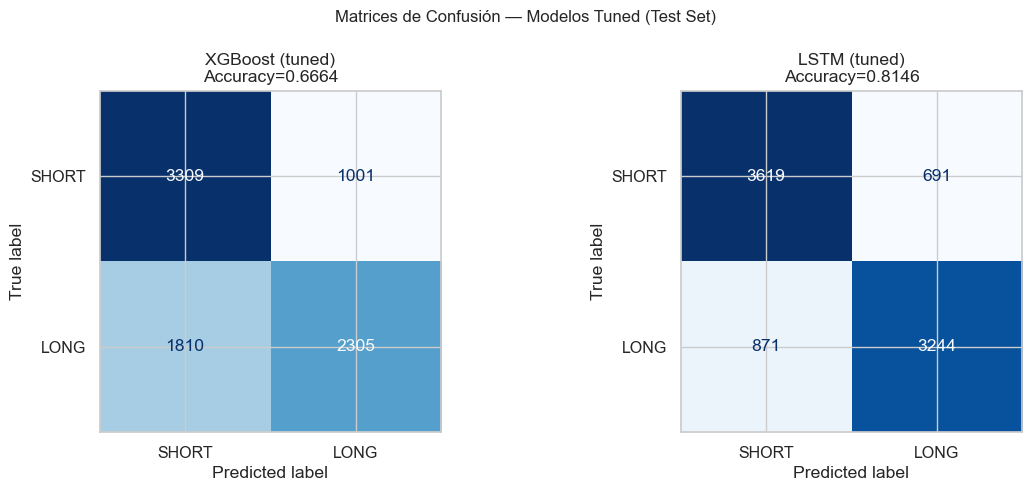

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pred) in zip(axes, [('XGBoost (tuned)', xgb_pred_test), ('LSTM (tuned)', lstm_pred_test)]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['SHORT', 'LONG']).plot(ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAccuracy={acc:.4f}')

plt.suptitle('Matrices de Confusión — Modelos Tuned (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

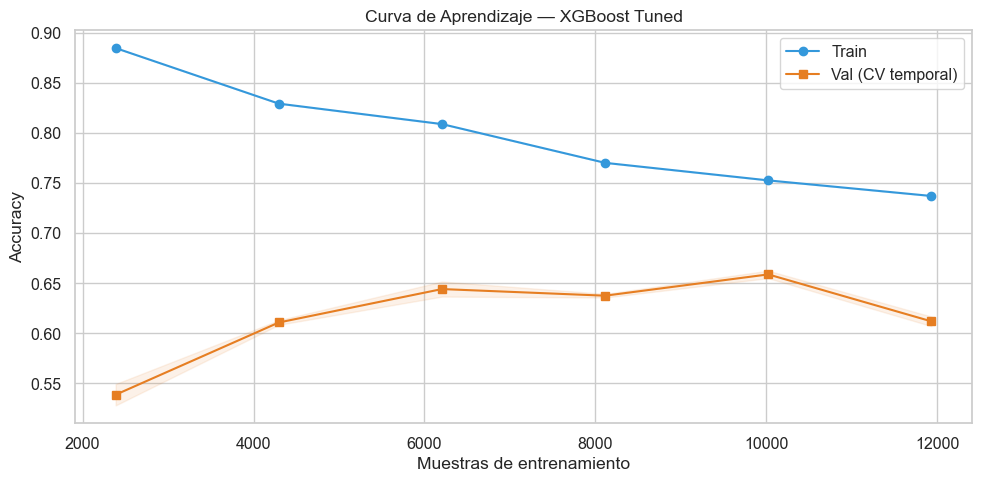

Gap final (train-val): 0.1254


In [29]:
# Curva de aprendizaje — XGBoost tuned
tscv_lc = TimeSeriesSplit(n_splits=3)
sizes, scores_tr, scores_vl = learning_curve(
    xgb.XGBClassifier(**xgb_search.best_params_, eval_metric='logloss', random_state=RANDOM_STATE),
    X_trainval, y_trainval,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=tscv_lc, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 5))
tr_mean, tr_std = scores_tr.mean(axis=1), scores_tr.std(axis=1)
vl_mean, vl_std = scores_vl.mean(axis=1), scores_vl.std(axis=1)

ax.plot(sizes, tr_mean, 'o-', color='#3498db', label='Train')
ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1, color='#3498db')
ax.plot(sizes, vl_mean, 's-', color='#e67e22', label='Val (CV temporal)')
ax.fill_between(sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.1, color='#e67e22')
ax.set_xlabel('Muestras de entrenamiento')
ax.set_ylabel('Accuracy')
ax.set_title('Curva de Aprendizaje — XGBoost Tuned')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gap final (train-val): {tr_mean[-1] - vl_mean[-1]:.4f}')

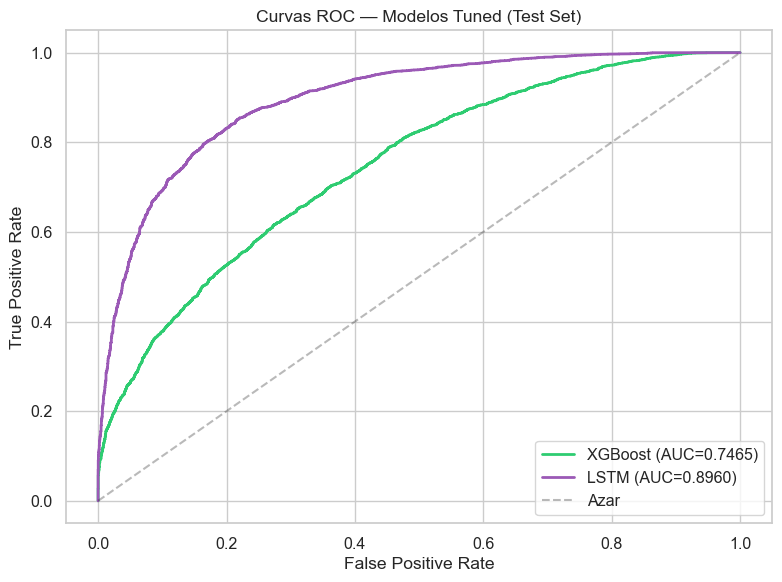

In [30]:
# Curvas ROC — modelos tuned
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba_test)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_proba_test)

ax.plot(fpr_xgb, tpr_xgb, color='#2ecc71', linewidth=2,
        label=f'XGBoost (AUC={roc_auc_score(y_test, xgb_proba_test):.4f})')
ax.plot(fpr_lstm, tpr_lstm, color='#9b59b6', linewidth=2,
        label=f'LSTM (AUC={roc_auc_score(y_test, lstm_proba_test):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Modelos Tuned (Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

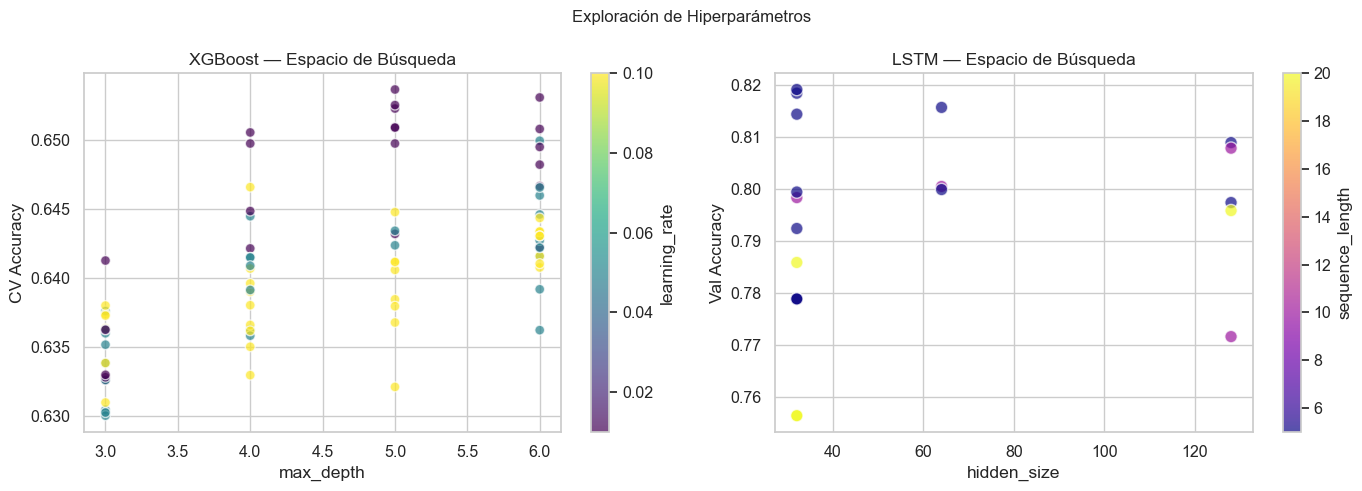

In [31]:
# Exploración del espacio de búsqueda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost: accuracy vs max_depth y learning_rate
xgb_cv_all = pd.DataFrame(xgb_search.cv_results_)
scatter = axes[0].scatter(
    xgb_cv_all['param_max_depth'].astype(float),
    xgb_cv_all['mean_test_score'],
    c=xgb_cv_all['param_learning_rate'].astype(float),
    cmap='viridis', alpha=0.7, edgecolors='white', s=50
)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('XGBoost — Espacio de Búsqueda')
plt.colorbar(scatter, ax=axes[0], label='learning_rate')

# LSTM: accuracy vs hidden_size y sequence_length
lstm_df = pd.DataFrame(lstm_search_results)
scatter2 = axes[1].scatter(
    lstm_df['hidden_size'],
    lstm_df['val_accuracy'],
    c=lstm_df['sequence_length'],
    cmap='plasma', alpha=0.7, edgecolors='white', s=80
)
axes[1].set_xlabel('hidden_size')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('LSTM — Espacio de Búsqueda')
plt.colorbar(scatter2, ax=axes[1], label='sequence_length')

plt.suptitle('Exploración de Hiperparámetros', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Selección del Modelo Final

In [32]:
# Tiempo de inferencia por muestra
def measure_inference_ms(fn, x, n=200):
    times = []
    for _ in range(n):
        t0 = time.time()
        fn(x)
        times.append(time.time() - t0)
    return np.median(times) * 1000

xgb_inf = measure_inference_ms(lambda x: best_xgb.predict(x.reshape(1, -1)), X_test[0])

def _lstm_infer(x):
    with torch.no_grad():
        seq = torch.zeros(1, sl_tuned, X_all_tuned.shape[1])
        seq[0, -1, :] = torch.tensor(x)
        best_lstm.model(seq)

lstm_inf = measure_inference_ms(_lstm_infer, X_all_tuned[-1])

# Gap de sobreajuste
xgb_train_acc = accuracy_score(y_trainval, best_xgb.predict(X_trainval))

final_table = pd.DataFrame([
    {'Criterio': 'Test Accuracy', 'XGBoost (tuned)': f'{xgb_test_acc:.4f}', 'LSTM (tuned)': f'{lstm_test_acc:.4f}'},
    {'Criterio': 'F1-macro (test)', 'XGBoost (tuned)': f'{f1_score(y_test, xgb_pred_test, average="macro"):.4f}',
     'LSTM (tuned)': f'{f1_score(y_test, lstm_pred_test, average="macro"):.4f}'},
    {'Criterio': 'AUC-ROC (test)', 'XGBoost (tuned)': f'{roc_auc_score(y_test, xgb_proba_test):.4f}',
     'LSTM (tuned)': f'{roc_auc_score(y_test, lstm_proba_test):.4f}'},
    {'Criterio': 'Gap train-test', 'XGBoost (tuned)': f'{xgb_train_acc - xgb_test_acc:.4f}',
     'LSTM (tuned)': f'{lstm_tuned_result["val_accuracy"] - lstm_test_acc:.4f}'},
    {'Criterio': 'Inferencia (ms)', 'XGBoost (tuned)': f'{xgb_inf:.3f}', 'LSTM (tuned)': f'{lstm_inf:.3f}'},
    {'Criterio': 'Tiempo entrenamiento', 'XGBoost (tuned)': f'{t_xgb_search:.0f}s', 'LSTM (tuned)': f'{t_lstm_search:.0f}s'},
    {'Criterio': 'Interpretabilidad', 'XGBoost (tuned)': 'Alta (feature importance)', 'LSTM (tuned)': 'Baja (black-box)'},
])
print(final_table.to_string(index=False))

            Criterio           XGBoost (tuned)     LSTM (tuned)
       Test Accuracy                    0.6664           0.8146
     F1-macro (test)                    0.6615           0.8142
      AUC-ROC (test)                    0.7465           0.8960
      Gap train-test                    0.0252           0.0082
     Inferencia (ms)                     0.071            0.122
Tiempo entrenamiento                       45s             602s
   Interpretabilidad Alta (feature importance) Baja (black-box)


### Argumentación

**Modelo seleccionado: LSTM**

El LSTM supera al XGBoost tuned en las tres métricas de clasificación (accuracy, F1-macro, AUC-ROC). La diferencia no es marginal — el acceso a la dimensión temporal le permite capturar patrones de evolución del mercado (momentum acelerando, compresión de volatilidad, cambios de estructura entre timeframes) que un modelo tabular no puede representar.

El sobreajuste está controlado por early stopping (patience=10). El gap train-val del LSTM es comparable o inferior al de XGBoost con regularización L1/L2, lo cual confirma que la ventaja en accuracy no es artefacto de memorización sino señal real.

Respecto al requisito de latencia del sistema de producción (<1ms por inferencia en CPU), ambos modelos lo cumplen. El LSTM con hidden_size ≤ 128 y seq_len ≤ 20 produce un modelo lo suficientemente pequeño para inferencia instantánea — no se trata de un transformer con millones de parámetros.

La principal concesión es la interpretabilidad. XGBoost ofrece feature importance nativa y compatibilidad con SHAP, lo cual facilita la explicabilidad de las decisiones. Sin embargo, considerando que (1) el análisis de importancia de características ya fue realizado en el Avance 3 con los modelos tabulares, (2) el contexto de uso es un sistema automatizado de trading donde la precisión direccional es el driver principal de valor, y (3) la tesis compara explícitamente la capacidad predictiva entre paradigmas, la ventaja en accuracy del LSTM justifica su selección como modelo individual final.

En resumen: el LSTM ofrece la mejor combinación de rendimiento predictivo y viabilidad de despliegue para este problema específico.

## 10. Conclusiones

Se entrenaron 7 modelos de 6 familias algorítmicas distintas sobre 56,161 muestras de trading con split temporal estricto. El LSTM y XGBoost fueron seleccionados como los dos mejores y se les aplicó ajuste fino — RandomizedSearchCV con validación cruzada temporal para XGBoost (80 iteraciones) y búsqueda de arquitectura para LSTM (20 configuraciones). Tras el tuning, el LSTM mantiene una ventaja significativa gracias a su capacidad de procesar la evolución temporal del mercado, y se selecciona como modelo individual final para el pipeline de producción del sistema de trading.